# Experiment: Keypoints Time Series Analysis

What this notebook teaches:
- Load canonical CSV exports and rebuild frame-level keypoint objects.
- Compute knee, elbow, and hip angle trajectories.
- Derive smooth curves, angular velocity, and compact statistical features.
- Produce interpretable plots for downstream posture/gesture modeling.


In [1]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sumeyye-agac/human-pose-estimation-experiments.git"
REPO_NAME = "human-pose-estimation-experiments"
COLAB_REPO_DIR = Path("/content") / REPO_NAME

if "google.colab" in sys.modules:
    if not COLAB_REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    os.chdir(COLAB_REPO_DIR)

repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break

if repo_root is None:
    raise RuntimeError("Could not locate repository root containing src/.")

os.chdir(repo_root)
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

print(f"Using repo root: {repo_root}")


Using repo root: /Users/sumeyyeagac/Desktop/GitHub_Sumeyye/human-pose-estimation-experiments


In [2]:
def pip_install(*packages: str) -> None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *packages], check=True)

pip_install(
    "numpy<2",
    "pandas>=2.1,<2.3",
    "matplotlib>=3.8,<3.9",
    "scipy>=1.11,<1.12",
)


In [3]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from posebench.export import export_frames_to_csv
from posebench.features import compute_angular_velocity, extract_joint_angles, smooth_series, summarize_series_features
from posebench.keypoints_schema import CANONICAL_KEYPOINTS

csv_path = repo_root / "results" / "mediapipe_sequence_canonical.csv"
if not csv_path.exists():
    synthetic_frames = []
    for i in range(60):
        phase = i / 59
        keypoints = {}
        for j, name in enumerate(CANONICAL_KEYPOINTS):
            keypoints[name] = {
                "x": 220 + 80 * np.sin(phase * np.pi * 2 + j * 0.07),
                "y": 240 + 65 * np.cos(phase * np.pi * 2 + j * 0.05),
                "confidence": 0.8,
            }
        synthetic_frames.append(
            {
                "frame_index": i,
                "timestamp_ms": i * (1000 / 30.0),
                "person_id": 0,
                "tool": "synthetic",
                "schema": "coco17",
                "keypoints": keypoints,
            }
        )
    export_frames_to_csv(synthetic_frames, csv_path)
    print("Generated synthetic fallback CSV:", csv_path)

df = pd.read_csv(csv_path)
print(df.head(2))


   frame_index  timestamp_ms  person_id       tool  schema      nose_x  \
0            0      0.000000          0  mediapipe  coco17  982.595673   
1            1     33.333333          0  mediapipe  coco17         NaN   

       nose_y  nose_confidence  left_eye_x  left_eye_y  ...  \
0  760.625896         0.984591  990.060883  753.695433  ...   
1         NaN         0.000000         NaN         NaN  ...   

   left_knee_confidence  right_knee_x  right_knee_y  right_knee_confidence  \
0              0.642134    984.707222    823.442051               0.389296   
1              0.000000           NaN           NaN               0.000000   

   left_ankle_x  left_ankle_y  left_ankle_confidence  right_ankle_x  \
0   1014.093704    924.148421               0.758263     997.668915   
1           NaN           NaN               0.000000            NaN   

   right_ankle_y  right_ankle_confidence  
0     930.452471                0.479093  
1            NaN                0.000000  

[2 rows 

In [4]:
frames = []
for _, row in df.iterrows():
    keypoints = {}
    for name in CANONICAL_KEYPOINTS:
        keypoints[name] = {
            "x": row.get(f"{name}_x"),
            "y": row.get(f"{name}_y"),
            "confidence": row.get(f"{name}_confidence", 0.0),
        }
    frames.append(
        {
            "frame_index": int(row["frame_index"]),
            "timestamp_ms": float(row["timestamp_ms"]),
            "keypoints": keypoints,
        }
    )

joint_triplets = {
    "left_knee_angle": ("left_hip", "left_knee", "left_ankle"),
    "right_elbow_angle": ("right_shoulder", "right_elbow", "right_wrist"),
    "left_hip_angle": ("left_shoulder", "left_hip", "left_knee"),
}
angles_df = extract_joint_angles(frames, joint_triplets, min_confidence=0.2)
angles_df.head()


,frame_index,timestamp_ms,left_knee_angle,right_elbow_angle,left_hip_angle
0,0,0.000000,170.631574,174.459795,3.189695
1,1,33.333333,NaN,NaN,NaN
2,2,66.666667,172.689449,48.497345,171.841969
3,3,100.000000,123.493271,132.156574,149.112077
4,4,133.333333,143.769780,122.082963,159.346093


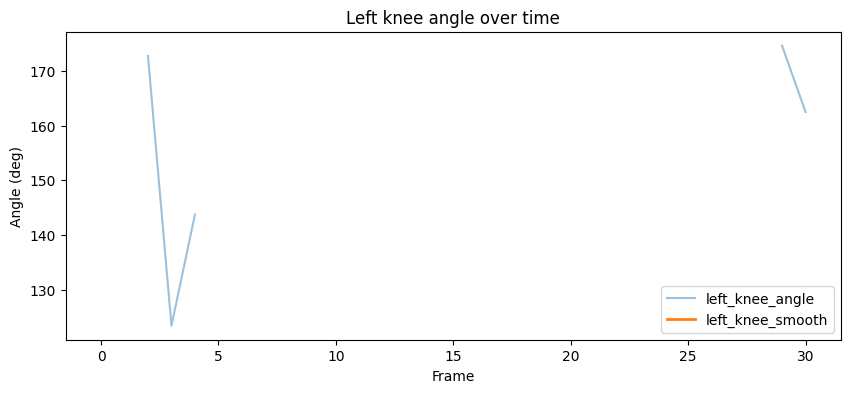

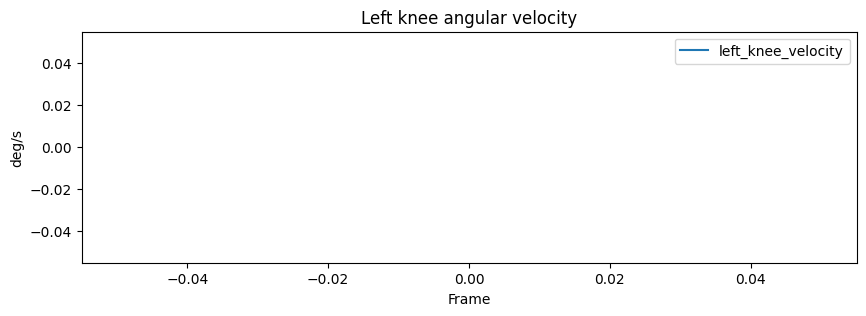

In [5]:
fps = 30.0
angles_df["left_knee_smooth"] = smooth_series(angles_df["left_knee_angle"], method="savgol")
angles_df["left_knee_velocity"] = compute_angular_velocity(angles_df["left_knee_smooth"], fps=fps)

plt.figure(figsize=(10, 4))
plt.plot(angles_df["frame_index"], angles_df["left_knee_angle"], alpha=0.45, label="left_knee_angle")
plt.plot(angles_df["frame_index"], angles_df["left_knee_smooth"], linewidth=2, label="left_knee_smooth")
plt.xlabel("Frame")
plt.ylabel("Angle (deg)")
plt.title("Left knee angle over time")
plt.legend()
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(angles_df["frame_index"], angles_df["left_knee_velocity"], label="left_knee_velocity")
plt.xlabel("Frame")
plt.ylabel("deg/s")
plt.title("Left knee angular velocity")
plt.legend()
plt.show()


In [6]:
feature_summary = {
    column: summarize_series_features(angles_df[column].to_numpy())
    for column in ["left_knee_angle", "right_elbow_angle", "left_hip_angle"]
}
summary_path = repo_root / "results" / "timeseries_feature_summary.json"
summary_path.write_text(json.dumps(feature_summary, indent=2) + "\n", encoding="utf-8")
feature_summary


{'left_knee_angle': {'mean': 161.70993470294582,
  'std': 17.341885571236553,
  'min': 123.4932713070705,
  'max': 174.556766110591,
  'peak_count': 3},
 'right_elbow_angle': {'mean': 131.7444054103567,
  'std': 38.069056012447426,
  'min': 48.497345239678324,
  'max': 174.45979525580466,
  'peak_count': 1},
 'left_hip_angle': {'mean': 65.33198771268444,
  'std': 73.73317760999274,
  'min': 3.1896952851999685,
  'max': 171.84196887840324,
  'peak_count': 3}}

From these trajectories and summary features, a downstream gesture or posture classifier can be built with classical ML or lightweight sequence models.
